In [ ]:
import os
import zipfile
import shutil
import uuid
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive
drive.mount('/content/drive')

# ================================
# CONFIGURACIÓN GENERAL
# ================================
IMG_SIZE   = (256, 320)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.001
SEED       = 123
THRESHOLD  = 0.45    # umbral de decisión (score >= THRESHOLD → MENOR)

MODEL_DIR = '/content/modelos_imagenes_menores'
os.makedirs(MODEL_DIR, exist_ok=True)

ZIP_PATH     = '/content/drive/MyDrive/imagenes_menores.zip'
EXTRACT_PATH = '/content/dataset'
SRC_PATH     = '/content/dataset/face_age'
DST_PATH     = '/content/dataset_clasificado'

print('Setup completado')

Mounted at /content/drive
Setup completado


In [ ]:
# ================================
# FUNCIONES DE PREPARACIÓN
# ================================

def descomprimir_dataset(zip_path, extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print('Dataset descomprimido')

def encontrar_face_age(base_path):
    for root, dirs, files in os.walk(base_path):
        if 'face_age' in dirs:
            return os.path.join(root, 'face_age')
    return None

def clasificar_dataset(src_path, dst_path):
    os.makedirs(dst_path + '/menor', exist_ok=True)
    os.makedirs(dst_path + '/mayor', exist_ok=True)
    for folder in os.listdir(src_path):
        folder_path = os.path.join(src_path, folder)
        if not folder.isdigit():
            continue
        edad = int(folder)
        for img in os.listdir(folder_path):
            src_img = os.path.join(folder_path, img)
            if not os.path.isfile(src_img):
                continue
            nombre = f'{edad}_{uuid.uuid4().hex[:8]}.jpg'
            destino = 'menor' if edad < 18 else 'mayor'
            shutil.copy(src_img, os.path.join(dst_path, destino, nombre))
    print('Dataset clasificado')

def ver_distribucion(dst_path):
    menores = len(os.listdir(dst_path + '/menor'))
    mayores = len(os.listdir(dst_path + '/mayor'))
    print(f'Menores: {menores} | Mayores: {mayores}')

In [ ]:
# ================================
# PREPARAR DATASET
# ================================

if not os.path.exists(DST_PATH):
    print('Dataset no encontrado, procesando...')
    descomprimir_dataset(ZIP_PATH, EXTRACT_PATH)
    SRC_PATH = encontrar_face_age(EXTRACT_PATH)
    if SRC_PATH is None:
        raise ValueError('No se encontró la carpeta face_age')
    clasificar_dataset(SRC_PATH, DST_PATH)
    ver_distribucion(DST_PATH)
else:
    print('Dataset ya preparado')
    ver_distribucion(DST_PATH)

def get_imagenes(dst_path=DST_PATH):
    train_dataset = image_dataset_from_directory(
        dst_path,
        validation_split=0.2,
        subset='training',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='int'
    )
    validation_dataset = image_dataset_from_directory(
        dst_path,
        validation_split=0.2,
        subset='validation',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='int'
    )
    print('Clases detectadas:', train_dataset.class_names)
    return train_dataset, validation_dataset

train_d, validation_d = get_imagenes()
class_names = train_d.class_names
print(f'label 0 = {class_names[0]} | label 1 = {class_names[1]}')
print(f'score >= {THRESHOLD}  →  MENOR')

# Balanceo de clases
n_menores = len(os.listdir(DST_PATH + '/menor'))
n_mayores = len(os.listdir(DST_PATH + '/mayor'))
labels_array = np.array([0] * n_mayores + [1] * n_menores)
weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=labels_array)
class_weight = dict(enumerate(weights))
print(f'class_weight: {class_weight}')

Dataset no encontrado, procesando...
Dataset descomprimido
Dataset clasificado
Menores: 3925 | Mayores: 5853
Found 9778 files belonging to 2 classes.
Using 7823 files for training.
Found 9778 files belonging to 2 classes.
Using 1955 files for validation.
Clases detectadas: ['mayor', 'menor']
label 0 = mayor | label 1 = menor
score >= 0.45  →  MENOR
class_weight: {0: np.float64(0.8352981377071588), 1: np.float64(1.2456050955414013)}


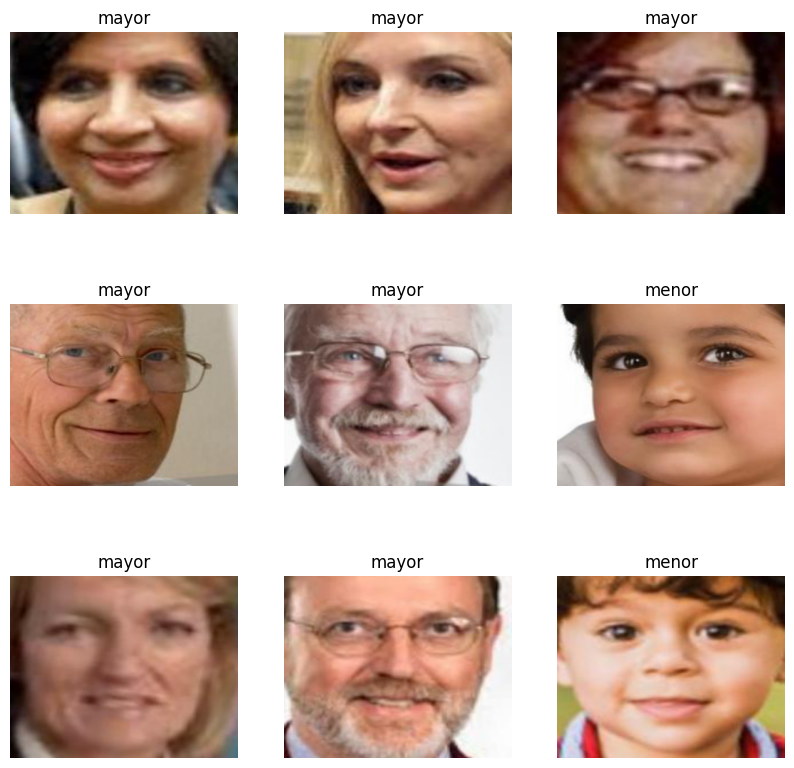

In [ ]:
# ================================
# VISUALIZAR MUESTRAS
# ================================

plt.figure(figsize=(10, 10))
for images, labels in train_d.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')

In [ ]:
# ================================
# ARQUITECTURA CNN BÁSICA
# ================================

def get_model_basico(
    input_shape=(256, 320, 3),
    conv1=32, conv2=64, conv3=128,
    dense1=64, dense2=32,
    kernel1=(3, 3), kernel2=(5, 5), kernel3=(3, 3),
    stride2=2
):
    inp = layers.Input(shape=input_shape)

    # Bloque 1
    x = layers.Conv2D(conv1, kernel1, padding='same', activation='relu')(inp)
    x = layers.Conv2D(conv1, kernel1, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 2
    x = layers.Conv2D(conv2, kernel2, strides=stride2, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 3
    x = layers.Conv2D(conv3, kernel3, padding='same', activation='relu')(x)

    # Clasificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense1, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(dense2, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    model.summary()
    return model

In [ ]:
# ================================
# NORMALIZAR
# ================================

def normalizar(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_norm = train_d.map(normalizar).prefetch(AUTOTUNE)
val_norm   = validation_d.map(normalizar).prefetch(AUTOTUNE)

In [2]:
# ================================
# CALLBACKS Y FUNCIÓN DE GRÁFICAS
# ================================

def graficar(history, title=''):
    slots = [
        ('accuracy', 'Accuracy', 'max'),
        ('loss',     'Loss',     'min'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, (key, label, mode) in zip(axes, slots):
        train_vals = history.history[key]
        val_vals   = history.history[f'val_{key}']
        epochs     = list(range(1, len(train_vals) + 1))

        train_best = max(train_vals) if mode == 'max' else min(train_vals)
        val_best   = max(val_vals)   if mode == 'max' else min(val_vals)

        ax.plot(epochs, train_vals, marker='o', markersize=4, label=f'train  {train_best:.2f}')
        ax.plot(epochs, val_vals,   marker='o', markersize=4, label=f'val    {val_best:.2f}')
        ax.set_title(f'{title} — {label}')
        ax.set_ylim(0, 1)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Callbacks para fase 1 (base congelada):
# - ModelCheckpoint y EarlyStopping monitorizan val_loss: ambos apuntan al mismo punto,
#   el de mejor generalización (antes del sobreajuste).
# - El recall se mide en la evaluación final, no se usa para decidir qué guardar.
def get_callbacks(model_name):
    path = os.path.join(MODEL_DIR, f'{model_name}.keras')
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=path,
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

## Experimento 1 — CNN básica sin augmentation

In [ ]:
recall_cnn1 = tf.keras.metrics.Recall(thresholds=THRESHOLD, name='recall_menor')

modelo_cnn = get_model_basico()

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy', recall_cnn1]
)

history_cnn = modelo_cnn.fit(
    train_norm,
    validation_data=val_norm,
    epochs=EPOCHS,
    callbacks=get_callbacks('cnn_sin_aug'),
    class_weight=class_weight
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 320, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 320, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 80, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,633 (568.88 KB)

 Trainable params: 145,633 (568.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.4825 - loss: 0.6915 - recall_menor: 0.9984
Epoch 1: val_loss improved from None to 0.68264, saving model to /content/modelos_imagenes_menores/cnn_sin_aug.keras

Epoch 1: finished saving model to /content/modelos_imagenes_menores/cnn_sin_aug.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 59s 175ms/step - accuracy: 0.5131 - loss: 0.6914 - recall_menor: 0.9965 - val_accuracy: 0.5990 - val_loss: 0.6826 - val_recall_menor: 1.0000 - learning_rate: 0.0010
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6017 - loss: 0.6852 - recall_menor: 0.8980
Epoch 2: val_loss improved from 0.68264 to 0.62673, saving model to /content/modelos_imagenes_menores/cnn_sin_aug.keras

Epoch 2: finished saving model to /content/modelos_imagenes_menores/cnn_sin_aug.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 34s 140ms/step - accuracy: 0.6131 - loss: 0.6729 - recall_menor: 0.7812 - val_accuracy: 0.6900 - val_loss: 0.6267 - val_recall_menor: 0.5771 - l

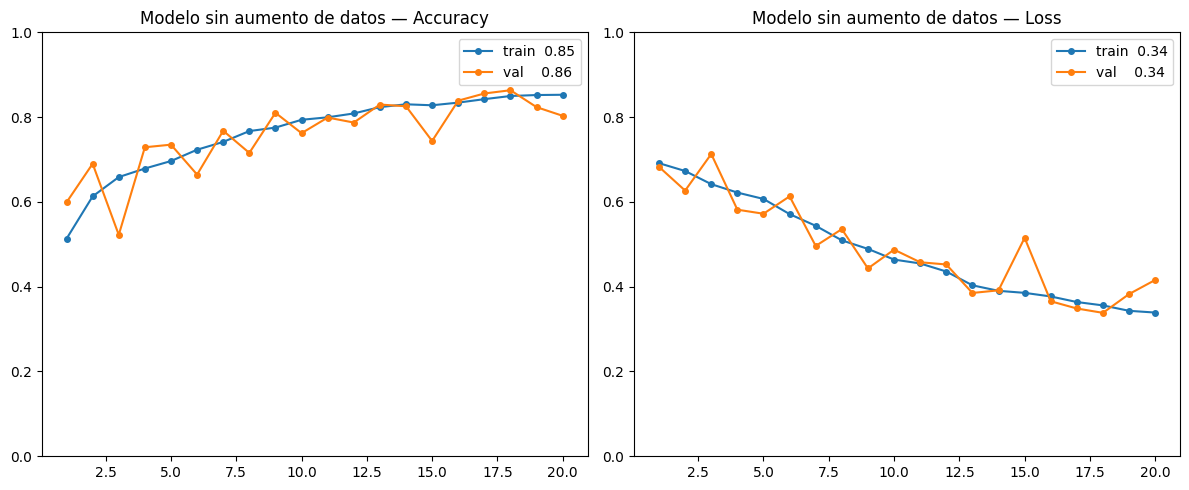

In [26]:
graficar(history_cnn, 'Modelo sin aumento de datos')

## Experimento 2 — CNN básica con augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def augmentar(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_aug = train_norm.map(augmentar).prefetch(AUTOTUNE)
val_aug   = val_norm   # validación sin augmentation

In [23]:
recall_cnn2 = tf.keras.metrics.Recall(thresholds=THRESHOLD, name='recall_menor')

# Reutilizamos el mismo modelo (continúa desde los pesos del exp. 1)
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy', recall_cnn2]
)

history_aug = modelo_cnn.fit(
    train_aug,
    validation_data=val_aug,
    epochs=EPOCHS,
    callbacks=get_callbacks('cnn_con_aug'),
    class_weight=class_weight
)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.8130 - loss: 0.4145 - recall_menor: 0.8126
Epoch 1: val_loss improved from None to 0.41646, saving model to /content/modelos_imagenes_menores/cnn_con_aug.keras

Epoch 1: finished saving model to /content/modelos_imagenes_menores/cnn_con_aug.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 181s 711ms/step - accuracy: 0.8052 - loss: 0.4239 - recall_menor: 0.8083 - val_accuracy: 0.8164 - val_loss: 0.4165 - val_recall_menor: 0.8955 - learning_rate: 0.0010
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.8222 - loss: 0.4061 - recall_menor: 0.8039
Epoch 2: val_loss improved from 0.41646 to 0.38401, saving model to /content/modelos_imagenes_menores/cnn_con_aug.keras

Epoch 2: finished saving model to /content/modelos_imagenes_menores/cnn_con_aug.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 165s 673ms/step - accuracy: 0.8200 - loss: 0.4044 - recall_menor: 0.8051 - val_accuracy: 0.8338 - val_loss: 0.3840 - val_recall_menor: 0.8879 -

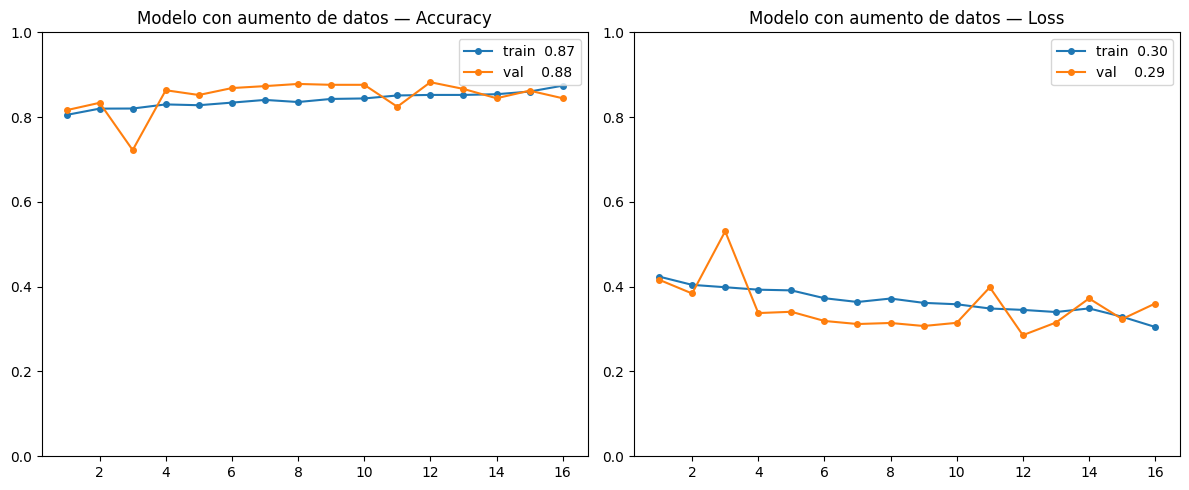

In [27]:
graficar(history_aug, 'Modelo con aumento de datos')

## Experimento 3 — ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Dataset sin normalizar — el preprocesado va dentro del modelo
train_res_raw, val_res_raw = get_imagenes()

train_resnet = train_res_raw.map(augmentar).prefetch(AUTOTUNE)
val_resnet   = val_res_raw.prefetch(AUTOTUNE)

Found 9778 files belonging to 2 classes.
Using 7823 files for training.
Found 9778 files belonging to 2 classes.
Using 1955 files for validation.
Clases detectadas: ['mayor', 'menor']


In [ ]:
def get_resnet():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(256, 320, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(256, 320, 3))
    x = tf.keras.layers.Lambda(resnet_preprocess)(inputs)  # preprocesado dentro del modelo
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

In [ ]:
recall_f1 = tf.keras.metrics.Recall(thresholds=THRESHOLD, name='recall_menor')

modelo_resnet = get_resnet()

modelo_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy', recall_f1]
)

history_resnet = modelo_resnet.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=EPOCHS,
    callbacks=get_callbacks('resnet_fase1'),
    class_weight=class_weight
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.8406 - loss: 0.3580 - recall_menor: 0.8477
Epoch 1: val_loss improved from None to 0.22642, saving model to /content/modelos_imagenes_menores/resnet_fase1.keras

Epoch 1: finished saving model to /content/modelos_imagenes_menores/resnet_fase1.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 201s 740ms/step - accuracy: 0.8708 - loss: 0.3104 - recall_menor: 0.8675 - val_accuracy: 0.9079 - val_loss: 0.2264 - val_recall_menor: 0.8904 - learning_rate: 0.0010
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.8946 - loss: 0.2565 - recall_menor: 0.8848
Epoch 2: val_loss did not improve from 0.22642
245/245 ━━━━━━━━━━━━━━━━━━━━ 173s 707ms/step - accuracy: 0.8925 - loss: 0.2624 - recall_menor: 0.8828 - val_accuracy: 0.8967 - val_loss: 0.2375 - val_recall_menor: 0.9121 - learning_rate: 0.0010
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9002 - loss: 0.2

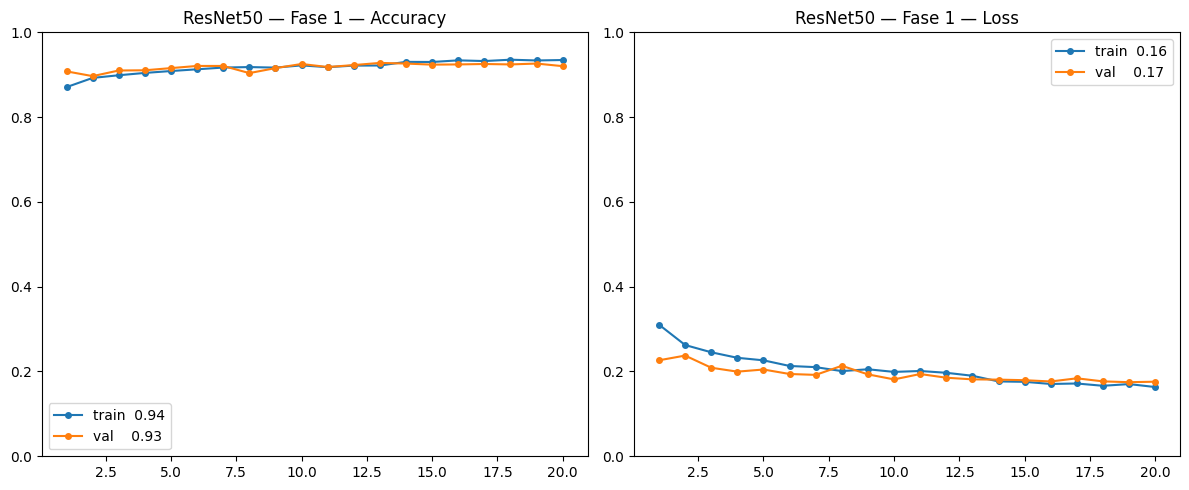

In [28]:
graficar(history_resnet, 'ResNet50 — Fase 1')

In [29]:
# Celda 1 — Predicciones y métricas
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    fbeta_score, balanced_accuracy_score,
    classification_report
)

scores_list, labels_list, imgs_list = [], [], []
for imgs, labels in val_resnet:
    s = modelo_resnet.predict(imgs, verbose=0).flatten()
    scores_list.append(s)
    labels_list.append(labels.numpy())
    imgs_list.append(imgs.numpy())

scores_res  = np.concatenate(scores_list)
y_true_res  = np.concatenate(labels_list).astype(int)
y_pred_res  = (scores_res >= THRESHOLD).astype(int)
imgs_res_np = np.concatenate(imgs_list)

idx_menor = class_names.index('menor')

tp = int(np.sum((y_pred_res == idx_menor) & (y_true_res == idx_menor)))
fp = int(np.sum((y_pred_res == idx_menor) & (y_true_res != idx_menor)))
fn = int(np.sum((y_pred_res != idx_menor) & (y_true_res == idx_menor)))
tn = int(np.sum((y_pred_res != idx_menor) & (y_true_res != idx_menor)))

recall_menor  = tp / (tp + fn) if (tp + fn) > 0 else 0
precision_men = tp / (tp + fp) if (tp + fp) > 0 else 0
f2_res        = fbeta_score(y_true_res, y_pred_res, beta=2, pos_label=idx_menor)
bal_acc_res   = balanced_accuracy_score(y_true_res, y_pred_res)
roc_auc_res   = roc_auc_score(y_true_res, scores_res)

print(f'Threshold        : {THRESHOLD}')
print(f'Recall MENOR     : {recall_menor:.4f}  <- metrica principal (minimizar FN)')
print(f'Precision MENOR  : {precision_men:.4f}')
print(f'F2-score         : {f2_res:.4f}  (pondera recall x2 sobre precision)')
print(f'Balanced Accuracy: {bal_acc_res:.4f}')
print(f'ROC-AUC          : {roc_auc_res:.4f}')
print(f'\nFN (menores no detectados)   : {fn}')
print(f'FP (adultos pixelados de mas): {fp}')
print()
print(classification_report(y_true_res, y_pred_res, target_names=class_names))

Threshold        : 0.45
Recall MENOR     : 0.9465  <- metrica principal (minimizar FN)
Precision MENOR  : 0.9218
F2-score         : 0.9415  (pondera recall x2 sobre precision)
Balanced Accuracy: 0.9463
ROC-AUC          : 0.9875

FN (menores no detectados)   : 42
FP (adultos pixelados de mas): 63

              precision    recall  f1-score   support

       mayor       0.96      0.95      0.95      1170
       menor       0.92      0.95      0.93       785

    accuracy                           0.95      1955
   macro avg       0.94      0.95      0.94      1955
weighted avg       0.95      0.95      0.95      1955



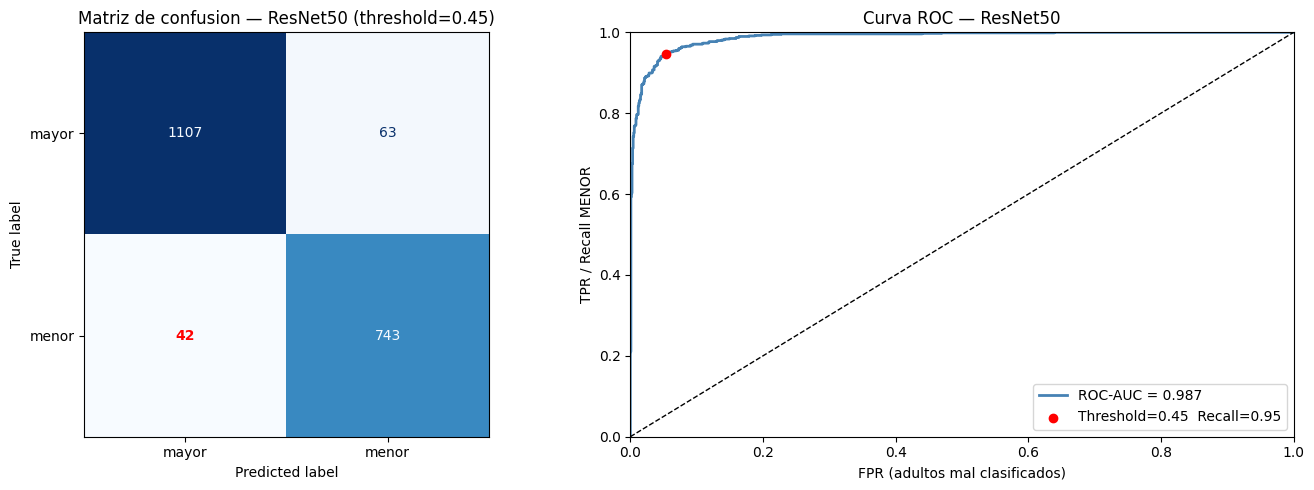

In [30]:
# Celda 2 — Matriz de confusión + curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_true_res, y_pred_res)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de confusion — ResNet50 (threshold={THRESHOLD})')

# Resaltar FN en rojo (fila menor, columna mayor)
n_cls = len(class_names)
for i in range(n_cls):
    for j in range(n_cls):
        if class_names[i] == 'menor' and class_names[j] != 'menor':
            axes[0].texts[i * n_cls + j].set_color('red')
            axes[0].texts[i * n_cls + j].set_fontweight('bold')

fpr_arr, tpr_arr, _ = roc_curve(y_true_res, scores_res)
fpr_op = fp / (fp + tn) if (fp + tn) > 0 else 0
axes[1].plot(fpr_arr, tpr_arr, lw=2, color='steelblue', label=f'ROC-AUC = {roc_auc_res:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr_op], [recall_menor], color='red', zorder=5,
                label=f'Threshold={THRESHOLD}  Recall={recall_menor:.2f}')
axes[1].set_xlabel('FPR (adultos mal clasificados)')
axes[1].set_ylabel('TPR / Recall MENOR')
axes[1].set_title('Curva ROC — ResNet50')
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

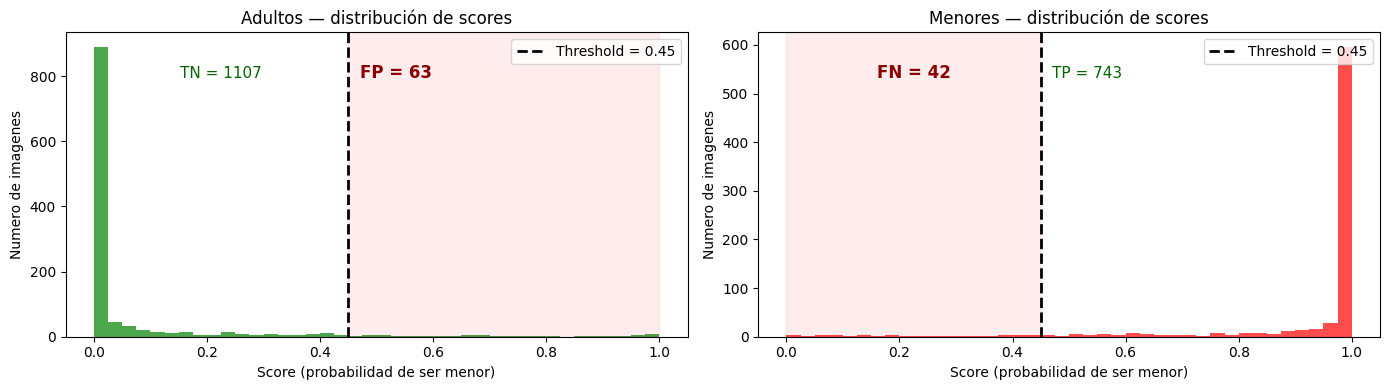

In [35]:
# Celda 3 — Histograma de scores por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

scores_menores = scores_res[y_true_res == idx_menor]
scores_adultos = scores_res[y_true_res != idx_menor]

# --- Adultos ---
axes[0].hist(scores_adultos, bins=40, color='green', alpha=0.7, range=(0, 1))
axes[0].axvline(THRESHOLD, color='black', lw=2, linestyle='--', label=f'Threshold = {THRESHOLD}')
ymax0 = axes[0].get_ylim()[1]
axes[0].axvspan(THRESHOLD, 1, alpha=0.07, color='red')
axes[0].text(THRESHOLD + 0.02, ymax0 * 0.85, f'FP = {fp}',
             ha='left', color='darkred', fontweight='bold', fontsize=12)
axes[0].text(THRESHOLD / 2, ymax0 * 0.85, f'TN = {tn}',
             ha='center', color='darkgreen', fontsize=11)
axes[0].set_xlabel('Score (probabilidad de ser menor)')
axes[0].set_ylabel('Numero de imagenes')
axes[0].set_title('Adultos — distribución de scores')
axes[0].legend()

# --- Menores ---
axes[1].hist(scores_menores, bins=40, color='red', alpha=0.7, range=(0, 1))
axes[1].axvline(THRESHOLD, color='black', lw=2, linestyle='--', label=f'Threshold = {THRESHOLD}')
ymax1 = axes[1].get_ylim()[1]
axes[1].axvspan(0, THRESHOLD, alpha=0.07, color='red')
axes[1].text(THRESHOLD / 2, ymax1 * 0.85, f'FN = {fn}',
             ha='center', color='darkred', fontweight='bold', fontsize=12)
axes[1].text(THRESHOLD + 0.02, ymax1 * 0.85, f'TP = {tp}',
             ha='left', color='darkgreen', fontsize=11)
axes[1].set_xlabel('Score (probabilidad de ser menor)')
axes[1].set_ylabel('Numero de imagenes')
axes[1].set_title('Menores — distribución de scores')
axes[1].legend()

plt.tight_layout()
plt.show()

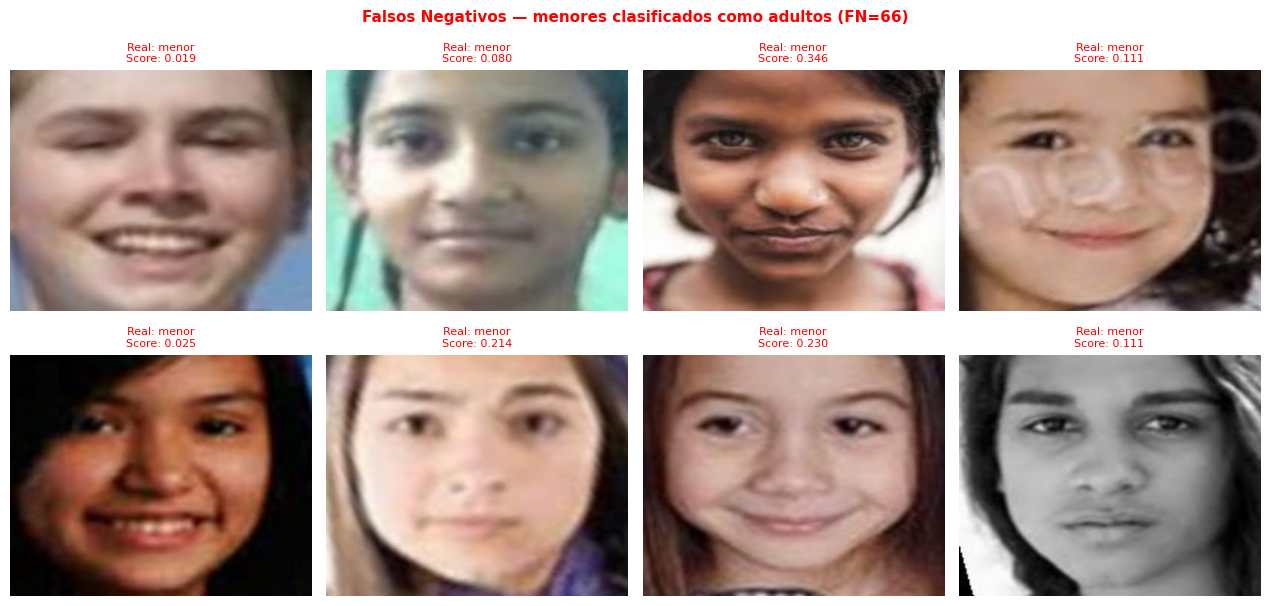

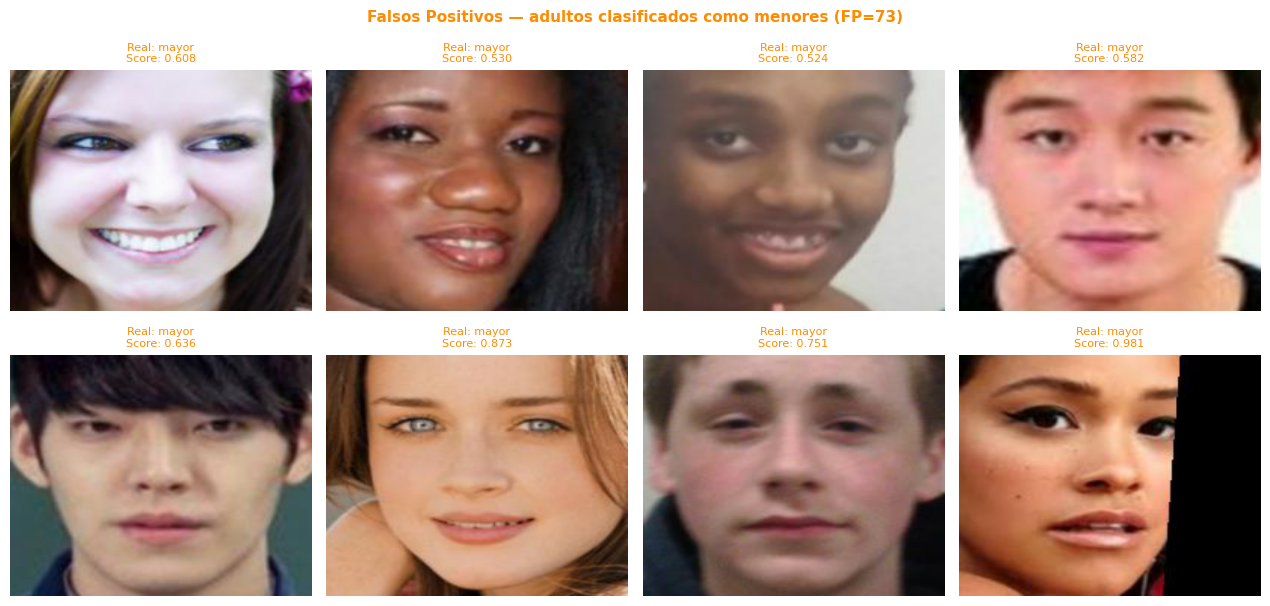

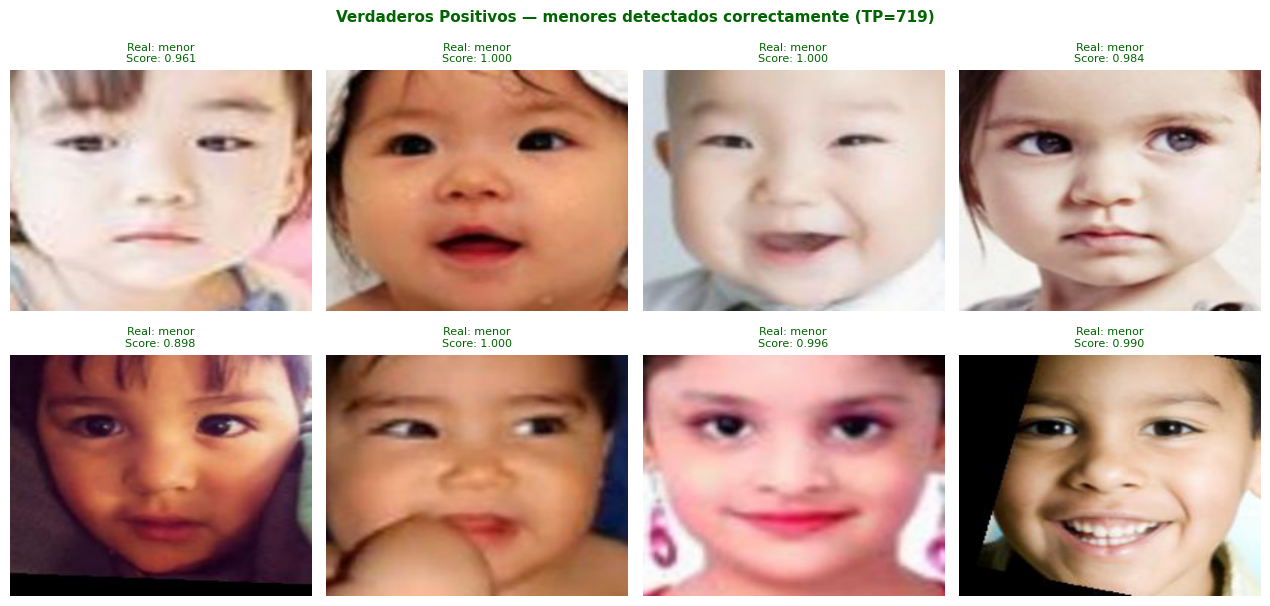

In [ ]:
# Celda 4 — Ejemplos clasificados bien y mal
def mostrar_grid(imgs_np, indices, scores, y_true, titulo, color):
    n = min(8, len(indices))
    if n == 0:
        print(f'Sin imagenes para: {titulo}')
        return
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(imgs_np[indices[i]].astype('uint8'))
            real = class_names[y_true[indices[i]]]
            sc   = scores[indices[i]]
            ax.set_title(f'Real: {real}\nScore: {sc:.3f}', fontsize=8, color=color)
        ax.axis('off')
    fig.suptitle(titulo, fontsize=11, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

fn_idx = np.where((y_true_res == idx_menor) & (y_pred_res != idx_menor))[0]
fp_idx = np.where((y_true_res != idx_menor) & (y_pred_res == idx_menor))[0]
tp_idx = np.where((y_true_res == idx_menor) & (y_pred_res == idx_menor))[0]

mostrar_grid(
    imgs_res_np, fn_idx, scores_res, y_true_res,
    f'Falsos Negativos — menores clasificados como adultos (FN={len(fn_idx)})',
    'red'
)
mostrar_grid(
    imgs_res_np, fp_idx, scores_res, y_true_res,
    f'Falsos Positivos — adultos clasificados como menores (FP={len(fp_idx)})',
    'darkorange'
)
mostrar_grid(
    imgs_res_np, tp_idx, scores_res, y_true_res,
    f'Verdaderos Positivos — menores detectados correctamente (TP={len(tp_idx)})',
    'darkgreen'
)

## Fine-tuning ResNet50

Descongelamos los últimos 30 layers de ResNet50 con un learning rate 10× más bajo para adaptar las características de alto nivel al dominio de caras.

Guardo a propósito el resultado de la época 2, que es el mejor resultado antes de que se empiece a sobreentrenar la red neuronal.

In [ ]:
base = modelo_resnet.get_layer('resnet50')
base.trainable = True

fine_tune_from = len(base.layers) - 30
for layer in base.layers[:fine_tune_from]:
    layer.trainable = False

print(f'Capas entrenables en ResNet50: {sum(1 for l in base.layers if l.trainable)} de {len(base.layers)}')

# Callbacks fine-tuning:
# - ModelCheckpoint y EarlyStopping ambos en val_loss: guardan y paran en el mismo punto,
#   el de mejor generalización antes del sobreajuste.
# - patience=2 porque el fine-tuning sobreajusta rápido con LR pequeño.
recall_ft = tf.keras.metrics.Recall(thresholds=THRESHOLD, name='recall_menor')

def get_callbacks_ft(model_name):
    path = os.path.join(MODEL_DIR, f'{model_name}.keras')
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=path,
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        )
    ]

modelo_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(LR / 10),
    loss='binary_crossentropy',
    metrics=['accuracy', recall_ft]
)

history_finetune = modelo_resnet.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=15,
    callbacks=get_callbacks_ft('resnet_fase2'),
    class_weight=class_weight
)

Capas entrenables en ResNet50: 30 de 175
Epoch 1/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.9914 - loss: 0.0295 - recall_menor: 0.9907
Epoch 1: val_loss improved from None to 0.24321, saving model to /content/modelos_imagenes_menores/resnet_fase2.keras

Epoch 1: finished saving model to /content/modelos_imagenes_menores/resnet_fase2.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 219s 796ms/step - accuracy: 0.9881 - loss: 0.0362 - recall_menor: 0.9885 - val_accuracy: 0.9453 - val_loss: 0.2432 - val_recall_menor: 0.9338 - learning_rate: 1.0000e-04
Epoch 2/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.9904 - loss: 0.0283 - recall_menor: 0.9916
Epoch 2: val_loss improved from 0.24321 to 0.23470, saving model to /content/modelos_imagenes_menores/resnet_fase2.keras

Epoch 2: finished saving model to /content/modelos_imagenes_menores/resnet_fase2.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 183s 747ms/step - accuracy: 0.9893 - loss: 0.0337 - recall_menor: 0.9898 - val_accuracy: 0.938

In [3]:
graficar(history_finetune, 'ResNet50 — Fine-tuning')

NameError: name 'history_finetune' is not defined

## Comparación final y guardado del mejor modelo

In [31]:
def evaluar(model, dataset, threshold=THRESHOLD):
    scores_all, y_true, y_pred = [], [], []
    for imgs, labels in dataset:
        s = model.predict(imgs, verbose=0).flatten()
        scores_all.extend(s)
        y_pred.extend((s >= threshold).astype(int))
        y_true.extend(labels.numpy().astype(int))
    scores_all = np.array(scores_all)
    y_true     = np.array(y_true)
    y_pred     = np.array(y_pred)
    idx_m = class_names.index('menor')
    tp = int(np.sum((y_pred == idx_m) & (y_true == idx_m)))
    fp = int(np.sum((y_pred == idx_m) & (y_true != idx_m)))
    fn = int(np.sum((y_pred != idx_m) & (y_true == idx_m)))
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f2        = fbeta_score(y_true, y_pred, beta=2, pos_label=idx_m)
    roc       = roc_auc_score(y_true, scores_all)
    return recall, precision, f2, roc, fn

rec_cnn,    prec_cnn,    f2_cnn,    roc_cnn,    fn_cnn    = evaluar(modelo_cnn,    val_aug)
rec_resnet, prec_resnet, f2_resnet, roc_resnet, fn_resnet = evaluar(modelo_resnet, val_resnet)

print(f'Threshold: {THRESHOLD}  (score >= {THRESHOLD} → MENOR)\n')
print('%-22s %8s %10s %8s %9s %5s' % ('Modelo', 'Recall', 'Precision', 'F2', 'ROC-AUC', 'FN'))
print('-' * 66)
print('%-22s %8.4f %10.4f %8.4f %9.4f %5d' % ('CNN básica + aug', rec_cnn,    prec_cnn,    f2_cnn,    roc_cnn,    fn_cnn))
print('%-22s %8.4f %10.4f %8.4f %9.4f %5d' % ('ResNet50',         rec_resnet, prec_resnet, f2_resnet, roc_resnet, fn_resnet))

mejor        = modelo_resnet if rec_resnet >= rec_cnn else modelo_cnn
nombre_mejor = 'ResNet50'    if rec_resnet >= rec_cnn else 'CNN básica'

OUTPUT_PATH = os.path.join(MODEL_DIR, 'modelo_menores.h5')
mejor.save(OUTPUT_PATH)

print(f'\nMejor modelo (por Recall MENOR): {nombre_mejor}')
print(f'Guardado en: {OUTPUT_PATH}')

Threshold: 0.45  (score >= 0.45 → MENOR)

Modelo                   Recall  Precision       F2   ROC-AUC    FN
------------------------------------------------------------------
CNN básica + aug         0.8344     0.8827   0.8436    0.9462   130
ResNet50                 0.9465     0.9218   0.9415    0.9875    42

Mejor modelo (por Recall MENOR): ResNet50
Guardado en: /content/modelos_imagenes_menores/modelo_menores.h5
